## LangChain Basics

### LangChain Version

In [22]:
import langchain
print(langchain.__version__)

1.4.2


In [11]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [12]:
from langchain_groq import ChatGroq

In [17]:
import requests
import os

api_key = os.environ.get("GROQ_API_KEY")
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

print(response.json())

{'object': 'list', 'data': [{'id': 'whisper-large-v3', 'object': 'model', 'created': 1693721698, 'owned_by': 'OpenAI', 'active': True, 'context_window': 448, 'public_apps': None, 'max_completion_tokens': 448, 'hugging_face_id': 'openai/whisper-large-v3', 'name': 'Whisper', 'input_modalities': ['audio'], 'output_modalities': ['transcription'], 'context_length': 448, 'max_output_length': 448}, {'id': 'openai/gpt-oss-120b', 'object': 'model', 'created': 1754408224, 'owned_by': 'OpenAI', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 65536, 'hugging_face_id': 'openai/gpt-oss-120b', 'name': 'GPT OSS 120B', 'input_modalities': ['text'], 'output_modalities': ['text'], 'context_length': 131072, 'max_output_length': 65536, 'pricing': {'prompt': '0.00000015', 'completion': '0.0000006', 'image': '0', 'request': '0', 'input_cache_read': '0.000000075'}, 'supported_sampling_parameters': ['temperature', 'top_p', 'stop', 'seed', 'max_tokens'], 'supported_featur

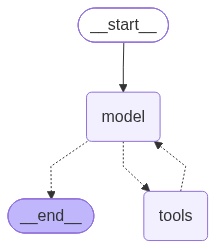

In [18]:
from langchain.agents import create_agent

def get_weather(city:str)-> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is sunny."

llm = ChatGroq(model="openai/gpt-oss-20b")  # cheapest option with tool support

agent = create_agent(
    model = llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [19]:
### run the agent
"""
Input to agent must b egiven in the form of dictionary
key : messages
value : <user message>
"""
agent.invoke({"messages":[{"role":"user","content":"What is the weather in New York?"}]})

{'messages': [HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}, id='ee48dfbe-59d0-4425-adb4-91e00c78047f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call get_weather with city "New York".', 'tool_calls': [{'id': 'fc_c01d3c98-7ff1-4934-8cd7-818effda1e2e', 'function': {'arguments': '{"city":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 138, 'total_tokens': 175, 'completion_time': 0.039761617, 'completion_tokens_details': {'reasoning_tokens': 13}, 'prompt_time': 0.006621703, 'prompt_tokens_details': None, 'queue_time': 0.353119292, 'total_time': 0.04638332}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_976a85d17a', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f86d-20f0-71c2-be31-33614fd75ed5-0', tool_calls=[{'name': 'get_w

In [21]:
# To display only the output
response = agent.invoke({"messages":[{"role":"user","content":"What is the weather in New York?"}]})
response["messages"][-1].content

'The weather in New\u202fYork is sunny.'